In [1]:
names_executionsCG = ["Elastic_CG_h0.0625_dt3.2e-05_T2.0",
                          "Elastic_CG_h0.03125_dt1.6e-05_T2.0",
                          "Elastic_CG_h0.015625_dt8e-06_T2.0",
                          "Elastic_CG_h0.0078125_dt4e-06_T2.0"]

names_executionsCG = ["Elastic_CG_h0.0625_dt3.2e-05_T1.0",
                          "Elastic_CG_h0.03125_dt1.6e-05_T1.0",
                          "Elastic_CG_h0.015625_dt8e-06_T1.0",
                          "Elastic_CG_h0.0078125_dt4e-06_T1.0",
                          "Elastic_CG_h0.00390625_dt2e-06_T1.0"]


In [2]:
import os
import numpy as np
import ufl
from dolfinx import fem, mesh
from basix.ufl import element
from mpi4py import MPI

In [3]:
path1 = os.path.join("results","test_single")
path_method = os.path.join("CG")
path_data = os.path.join("data")

In [ ]:
L_vessels = [1] # ,1,2
Ns = np.array([16, 32, 64, 128, 256])
ts = np.array([32e-6, 16e-6, 8e-6, 4e-6, 2e-6])*2
# *2 since we save half of the steps for save memory
hs = 1/Ns
variables = ['area', 'flux']

In [9]:
solutions_arr = []# np.empty((4, 3, 2, N), dtype=np.float64)
for n_file in range(len(Ns)):
    solution_i = np.empty((len(L_vessels), 2,Ns[n_file]+1, int(1/ts[n_file])), dtype=np.float64)
    for n_vessel in range(len(L_vessels)):
        name_vessel = f"vessel_{n_vessel}_solutions.npz"
        path = os.path.join(path1, path_method, names_executionsCG[n_file], path_data, name_vessel)
        arr = np.load(path)
        # solution_i_e = []
        len_t = len(arr['time'])
        for e, variable_e in enumerate(['area','flux']):
            print(n_file,n_vessel, e)
            # print(arr[variable_e].T.shape)
            added = arr[variable_e].T
            if n_file == 3:
                added = added # [:,:-1]
            if n_vessel == 2:
                solution_i[n_vessel, e,:] = added[::2,:]
            else:
                solution_i[n_vessel, e,:] = added
    #     solution_i.append(solution_i_e)
    solutions_arr.append(solution_i)      


0 0 0
0 0 1
1 0 0
1 0 1
2 0 0
2 0 1
3 0 0
3 0 1
4 0 0
4 0 1


In [10]:
sol_m1 = solutions_arr[-1]
sol_m2 = solutions_arr[-2]
rich = (4*sol_m1[:,:,::2,::2]-sol_m2)/3

In [11]:
diff = arr['time'][:-1] - arr['time'][1:]
arr['time']

array([4.00000e-06, 8.00000e-06, 1.20000e-05, ..., 9.99992e-01,
       9.99996e-01, 1.00000e+00], shape=(250000,))

In [12]:
errors = []
print(rich.shape)
for n_file in range(len(Ns)-1):
    arr = solutions_arr[n_file]
    print(arr.shape)
    errors_i = np.empty((len(L_vessels),2, int(1/ts[n_file])), dtype=np.float64)
    skip = 2**(len(Ns)-2-n_file)
    errors_i = (rich[:,:,::skip,::skip]-arr)**2
    errors.append(np.sqrt(errors_i.sum(axis=2)*hs[n_file]))

(1, 2, 129, 125000)
(1, 2, 17, 15625)
(1, 2, 33, 31250)
(1, 2, 65, 62500)
(1, 2, 129, 125000)


In [13]:
errors_max = np.empty((len(Ns)-1, len(L_vessels),2),dtype=np.float64)
for i in range(len(Ns)-1):
    errors_max[i,:,:] = errors[i].max(axis=2) 

In [14]:
errors_max

array([[[1.08851318e-03, 1.09358512e+00]],

       [[9.47557037e-04, 8.43159714e-01]],

       [[6.25106769e-04, 8.41030918e-01]],

       [[5.80267864e-04, 6.74665564e-01]]])

In [15]:
import matplotlib.pyplot as plt

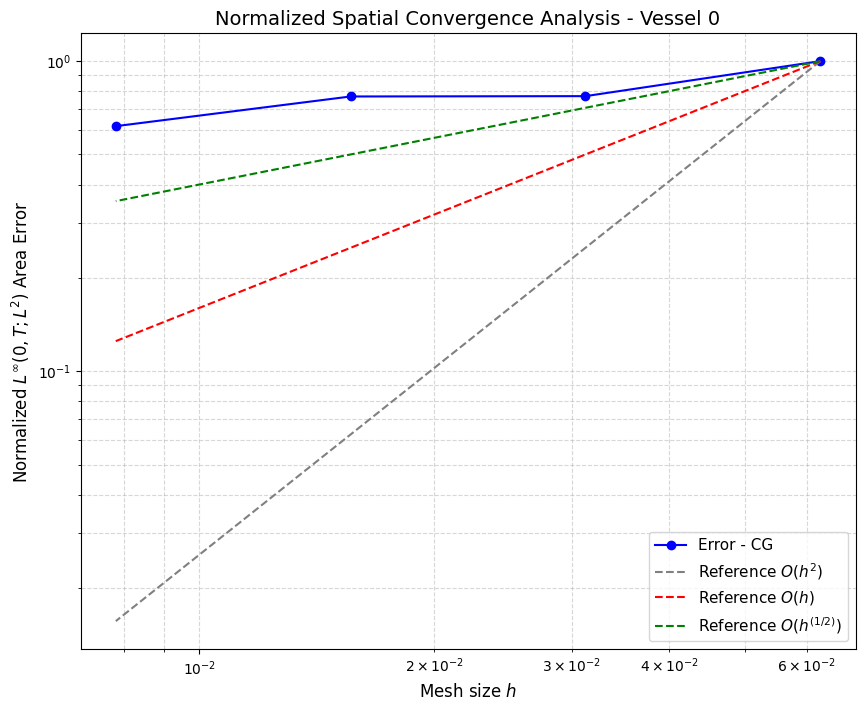

In [16]:
method_names = ["CG", "DG (LxF)", "DG (HLL)"]
colors = ['blue', 'orange', 'purple']
n_vessel = 0
hs_m1 = hs[:-1]

plt.figure(figsize=(10, 8))


# Extract the absolute area error for this method
area_errors = errors_max[:, n_vessel, 1]

# THE FIX: Normalize the error so it starts exactly at 1.0
normalized_errors = area_errors / area_errors[0]

# Plot the normalized error line
plt.loglog(hs_m1, normalized_errors, marker='o', linestyle='-', 
           color='blue', label=f'Error - CG')

# 2. Calculate the reference lines anchored to 1.0
# Since all normalized errors start at 1.0, our anchor is simply 1.0
anchor = 1.0 

h_square = anchor / (hs_m1[0]**2)   * (hs_m1**2)
h_scaled = anchor / (hs_m1[0])      * (hs_m1)
h_1_2    = anchor / (hs_m1[0]**0.5) * (hs_m1**0.5)

# 3. Plot the reference lines
plt.loglog(hs_m1, h_square, linestyle='--', color='gray', label='Reference $O(h^2)$')
plt.loglog(hs_m1, h_scaled, linestyle='--', color='red', label='Reference $O(h)$')
plt.loglog(hs_m1, h_1_2, linestyle='--', color='green', label='Reference $O(h^{(1/2)})$')

# 4. Formatting
plt.xlabel('Mesh size $h$', fontsize=12)
# Update the y-label to indicate it is normalized
plt.ylabel('Normalized $L^\infty(0,T; L^2)$ Area Error', fontsize=12) 
plt.title(f'Normalized Spatial Convergence Analysis - Vessel {n_vessel}', fontsize=14)
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.legend(fontsize=11)

plt.show()